# Домашнє завдання №5 — Частина 3

## Аналіз Amazon Top 50 Bestselling Books (2009–2019)

Датасет містить щорічні записи про 50 найпопулярніших книг Amazon за 2009–2019 роки.
Джерело: [Amazon Top 50 Bestselling Books 2009–2019](https://www.kaggle.com/datasets/sootersaalu/amazon-top-50-bestselling-books-2009-2019).

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-pastel")
pd.set_option("display.max_colwidth", 100)
print(f"Pandas version: {pd.__version__}")

Pandas version: 3.0.1


## 1–2. Читання CSV та перші п’ять рядків

In [2]:
df = pd.read_csv("bestsellers_with_categories.csv")
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (National Geographic Kids)",National Geographic Kids,4.8,7665,12,2019,Non Fiction


## 3. Розмір датасету

**Питання:** Про скільки книг зберігає дані датасет?

In [3]:
print("Розмір датасету:", df.shape)
print(f"Відповідь: датасет містить {df.shape[0]} записів про книги.")

Розмір датасету: (550, 7)
Відповідь: датасет містить 550 записів про книги.


## Зміна назв колонок на snake_case

In [4]:
df.columns = ["name", "author", "user_rating", "reviews", "price", "year", "genre"]
print(df.columns.tolist())

['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']


# Первинне дослідження даних

## Пропуски у стовпцях

**Питання:** Чи є в якихось змінних пропуски?

In [5]:
missing_values = df.isna().sum()
print(missing_values)
print("Відповідь: ні, пропусків у датасеті немає." if missing_values.sum() == 0 else "Відповідь: так, пропуски є.")

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64
Відповідь: ні, пропусків у датасеті немає.


## Унікальні жанри

**Питання:** Які є унікальні жанри?

In [6]:
genres = df["genre"].unique()
print("Унікальні значення:", genres)
print("Відповідь:", ", ".join(genres))

Унікальні значення: <StringArray>
['Non Fiction', 'Fiction']
Length: 2, dtype: str
Відповідь: Non Fiction, Fiction


## Розподіл цін — гістограма

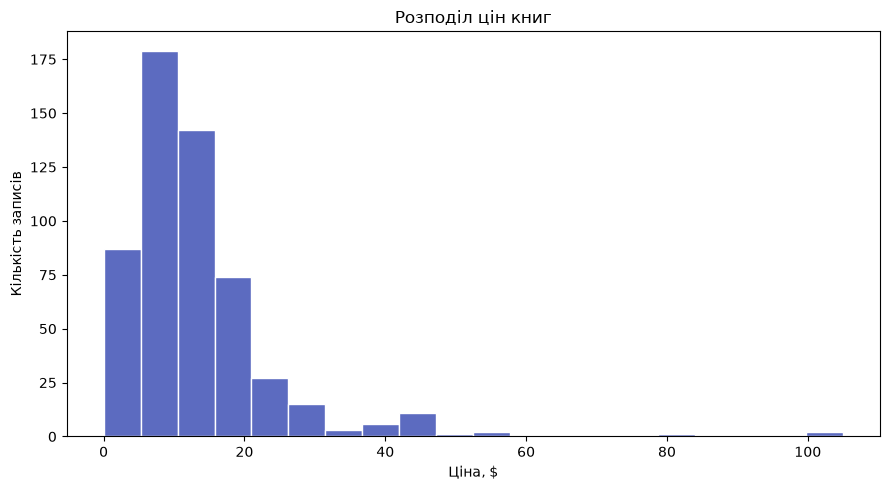

In [7]:
ax = df["price"].plot(kind="hist", bins=20, figsize=(9, 5), color="#5C6BC0", edgecolor="white", title="Розподіл цін книг")
ax.set_xlabel("Ціна, $")
ax.set_ylabel("Кількість записів")
plt.tight_layout()
plt.show()

## Основні характеристики ціни

In [8]:
max_price = df["price"].max()
min_price = df["price"].min()
mean_price = df["price"].mean()
median_price = df["price"].median()
print(f"Відповідь: максимальна ціна — ${max_price}.")
print(f"Відповідь: мінімальна ціна — ${min_price}.")
print(f"Відповідь: середня ціна — ${mean_price:.2f}.")
print(f"Відповідь: медіанна ціна — ${median_price:.2f}.")

Відповідь: максимальна ціна — $105.
Відповідь: мінімальна ціна — $0.
Відповідь: середня ціна — $13.10.
Відповідь: медіанна ціна — $11.00.


# Пошук та сортування даних

## Найвищий рейтинг і кількість книг із таким рейтингом

In [9]:
max_rating = df["user_rating"].max()
max_rating_count = (df["user_rating"] == max_rating).sum()
print(f"Відповідь: найвищий рейтинг — {max_rating}.")
print(f"Відповідь: такий рейтинг мають {max_rating_count} записів про книги.")

Відповідь: найвищий рейтинг — 4.9.
Відповідь: такий рейтинг мають 52 записів про книги.


## Книга з найбільшою кількістю відгуків

In [10]:
most_reviewed = df.loc[df["reviews"].idxmax()]
print(f"Відповідь: {most_reviewed['name']} — {most_reviewed['reviews']} відгуків.")

Відповідь: Where the Crawdads Sing — 87841 відгуків.

## Найдорожча книга серед тих, що потрапили до Топ-50 у 2015 році

In [11]:
books_2015 = df[df["year"] == 2015]
most_expensive_2015 = books_2015.loc[books_2015["price"].idxmax()]
print(f"Відповідь: {most_expensive_2015['name']} — ${most_expensive_2015['price']}.")

Відповідь: Publication Manual of the American Psychological Association, 6th Edition — $46.


## Кількість книг жанру Fiction у Топ-50 за 2010 рік

In [12]:
fiction_2010_count = ((df["genre"] == "Fiction") & (df["year"] == 2010)).sum()
print(f"Відповідь: {fiction_2010_count} записів.")

Відповідь: 20 записів.


## Кількість книг із рейтингом 4.9 у 2010 та 2011 роках

In [13]:
rating_49_2010_2011 = ((df["user_rating"] == 4.9) & (df["year"].isin([2010, 2011]))).sum()
print(f"Відповідь: {rating_49_2010_2011} запис.")

Відповідь: 1 запис.


## Сортування книг 2015 року дешевше за $8

In [14]:
inexpensive_2015 = df[(df["year"] == 2015) & (df["price"] < 8)].sort_values("price")
display(inexpensive_2015)
print(f"Відповідь: остання книга у списку — {inexpensive_2015.iloc[-1]['name']}.")

,name,author,user_rating,reviews,price,year,genre
507,To Kill a Mockingbird,Harper Lee,4.8,26234,0,2015,Fiction
54,Creative Haven Creative Cats Coloring Book (Adult Coloring),Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
206,Knock-Knock Jokes for Kids,Rob Elliott,4.5,3673,4,2015,Non Fiction
111,First 100 Words,Roger Priddy,4.7,17323,4,2015,Non Fiction
210,Laugh-Out-Loud Jokes for Kids,Rob Elliott,4.6,6990,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Coloring),Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
224,Love You Forever,Robert Munsch,4.8,18613,5,2015,Fiction
478,The Very Hungry Caterpillar,Eric Carle,4.9,19546,5,2015,Fiction


Відповідь: остання книга у списку — Old School (Diary of a Wimpy Kid #10).


# Агрегування даних та з’єднання таблиць

## Мінімальна та максимальна ціни за жанрами

In [15]:
genre_prices = df.groupby("genre")["price"].agg(["min", "max"])
display(genre_prices)
print(f"Відповідь: максимальна ціна Fiction — ${genre_prices.loc['Fiction', 'max']}.")
print(f"Відповідь: мінімальна ціна Fiction — ${genre_prices.loc['Fiction', 'min']}.")
print(f"Відповідь: максимальна ціна Non Fiction — ${genre_prices.loc['Non Fiction', 'max']}.")
print(f"Відповідь: мінімальна ціна Non Fiction — ${genre_prices.loc['Non Fiction', 'min']}.")

,min,max
genre,,
Fiction,0,82
Non Fiction,0,105


Відповідь: максимальна ціна Fiction — $82.
Відповідь: мінімальна ціна Fiction — $0.
Відповідь: максимальна ціна Non Fiction — $105.
Відповідь: мінімальна ціна Non Fiction — $0.


## Кількість книг для кожного автора

In [16]:
author_book_count = df.groupby("author")["name"].agg(book_count="count")
top_author = author_book_count["book_count"].idxmax()
top_author_count = author_book_count.loc[top_author, "book_count"]
print("Розмір таблиці:", author_book_count.shape)
print(f"Відповідь: таблиця має розмір {author_book_count.shape}.")
print(f"Відповідь: найбільше записів має {top_author} — {top_author_count}.")
author_book_count.sort_values("book_count", ascending=False).head()

Розмір таблиці: (248, 1)
Відповідь: таблиця має розмір (248, 1).
Відповідь: найбільше записів має Jeff Kinney — 12.


,book_count
author,
Jeff Kinney,12
Gary Chapman,11
Rick Riordan,11
Suzanne Collins,11
American Psychological Association,10


## Середній рейтинг для кожного автора

In [17]:
author_avg_rating = df.groupby("author")["user_rating"].agg(avg_rating="mean")
lowest_rated_author = author_avg_rating["avg_rating"].idxmin()
lowest_avg_rating = author_avg_rating.loc[lowest_rated_author, "avg_rating"]
print(f"Відповідь: мінімальний середній рейтинг має {lowest_rated_author}.")
print(f"Відповідь: середній рейтинг цього автора — {lowest_avg_rating:.2f}.")
author_avg_rating.sort_values("avg_rating").head()

Відповідь: мінімальний середній рейтинг має Donna Tartt.
Відповідь: середній рейтинг цього автора — 3.90.


,avg_rating
author,
Donna Tartt,3.9
Gallup,4.0
Gillian Flynn,4.0
Muriel Barbery,4.0
Ian K. Smith M.D.,4.1


## Об’єднання таблиць та сортування

In [18]:
authors_summary = pd.concat([author_book_count, author_avg_rating], axis=1)
authors_summary_sorted = authors_summary.sort_values(["book_count", "avg_rating"])
display(authors_summary_sorted.head())
print(f"Відповідь: перший автор у відсортованому списку — {authors_summary_sorted.index[0]}.")

,book_count,avg_rating
author,,
Muriel Barbery,1,4.0
Chris Cleave,1,4.1
Ian K. Smith M.D.,1,4.1
Pierre Dukan,1,4.1
Elizabeth Strout,1,4.2


Відповідь: перший автор у відсортованому списку — Muriel Barbery.


# Додаткові візуалізації

## Візуалізація 2. Частки жанрів

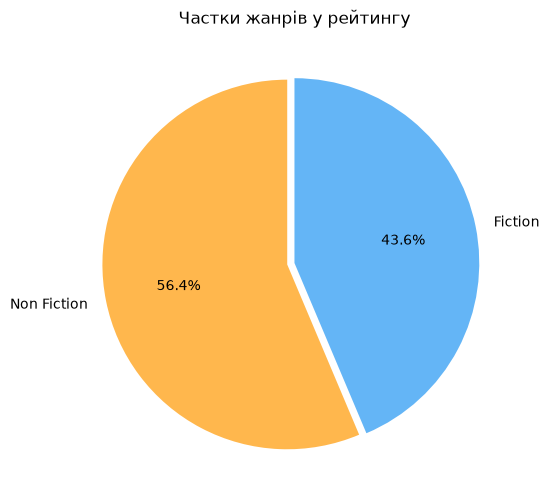

In [19]:
genre_counts = df["genre"].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(genre_counts.values, labels=genre_counts.index, autopct="%1.1f%%", startangle=90, colors=["#FFB74D", "#64B5F6"], explode=(0.04, 0))
ax.set_title("Частки жанрів у рейтингу")
plt.show()

## Візуалізація 3. Середній рейтинг за роками

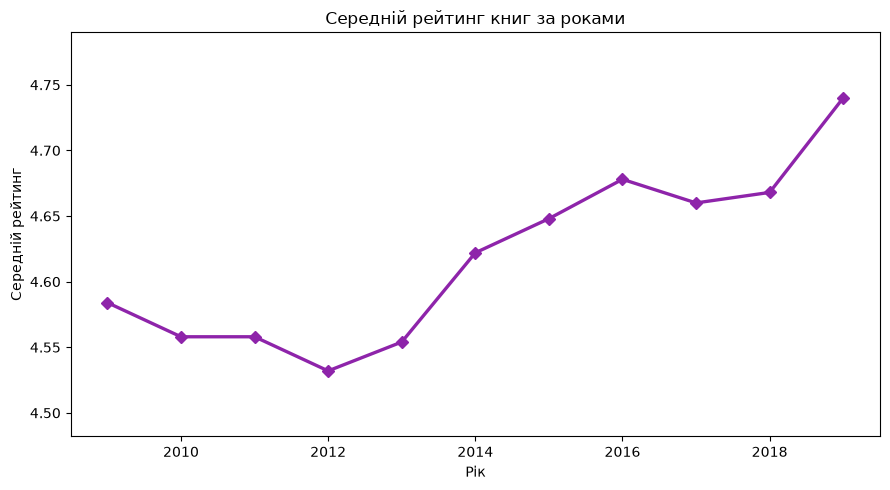

In [20]:
rating_by_year = df.groupby("year")["user_rating"].mean()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rating_by_year.index, rating_by_year.values, marker="D", linewidth=2.4, color="#8E24AA")
ax.set(title="Середній рейтинг книг за роками", xlabel="Рік", ylabel="Середній рейтинг")
ax.set_ylim(rating_by_year.min() - 0.05, rating_by_year.max() + 0.05)
plt.tight_layout()
plt.show()

## Візуалізація 4. Відгуки та рейтинг за жанрами

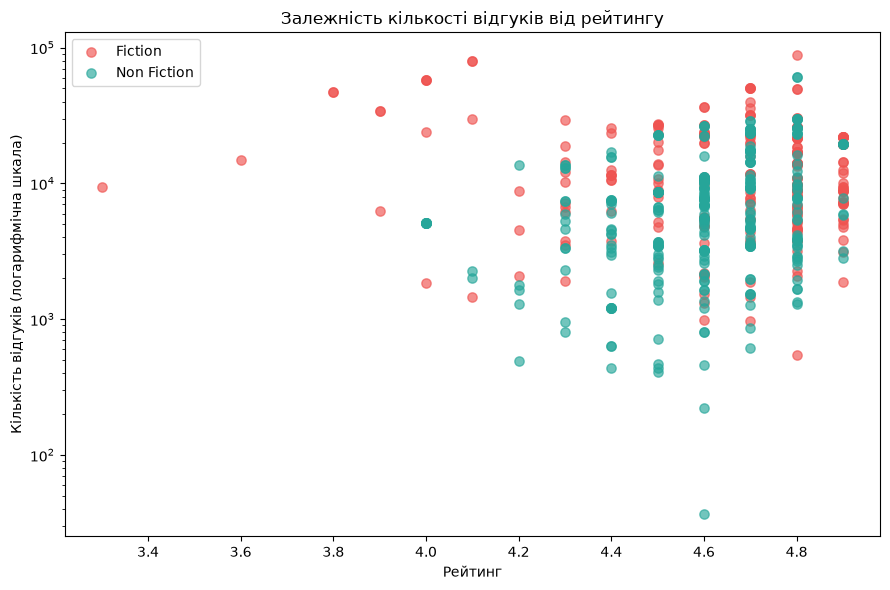

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"Fiction": "#EF5350", "Non Fiction": "#26A69A"}
for genre, subset in df.groupby("genre"):
    ax.scatter(subset["user_rating"], subset["reviews"], label=genre, alpha=0.65, s=45, color=colors[genre])
ax.set_yscale("log")
ax.set(title="Залежність кількості відгуків від рейтингу", xlabel="Рейтинг", ylabel="Кількість відгуків (логарифмічна шкала)")
ax.legend()
plt.tight_layout()
plt.show()

## Візуалізація 5. Автори з найбільшою кількістю потраплянь у рейтинг

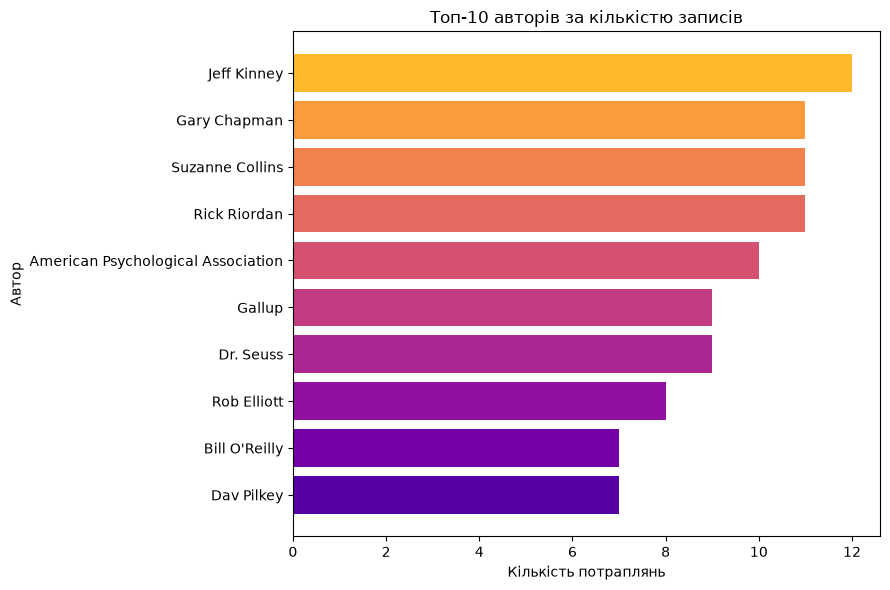

In [22]:
top_authors = author_book_count.nlargest(10, "book_count").sort_values("book_count")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_authors.index, top_authors["book_count"], color=plt.cm.plasma(np.linspace(0.15, 0.85, len(top_authors))))
ax.set(title="Топ-10 авторів за кількістю записів", xlabel="Кількість потраплянь", ylabel="Автор")
plt.tight_layout()
plt.show()